In [1]:
import pandas as pd
df = pd.read_csv("INFY.csv")

In [2]:
df.shape

(5306, 15)

In [3]:
df.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2000-01-03,INFOSYSTCH,EQ,14467.75,15625.00,15625.20,15625.00,15625.20,15625.20,15625.18,5137,8.026657e+12,NaN,NaN,NaN
1,2000-01-04,INFOSYSTCH,EQ,15625.20,16800.00,16875.25,16253.00,16875.25,16855.90,16646.38,56186,9.352937e+13,NaN,NaN,NaN
2,2000-01-05,INFOSYSTCH,EQ,16855.90,15701.00,16250.00,15507.45,15507.45,15507.45,15786.38,164605,2.598516e+14,NaN,NaN,NaN
3,2000-01-06,INFOSYSTCH,EQ,15507.45,15256.65,15300.00,14266.85,14266.85,14266.85,14462.82,81997,1.185908e+14,NaN,NaN,NaN
4,2000-01-07,INFOSYSTCH,EQ,14266.85,13125.50,13125.50,13125.50,13125.50,13125.50,13125.50,7589,9.960942e+12,NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5306 entries, 0 to 5305
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                5306 non-null   str    
 1   Symbol              5306 non-null   str    
 2   Series              5306 non-null   str    
 3   Prev Close          5306 non-null   float64
 4   Open                5306 non-null   float64
 5   High                5306 non-null   float64
 6   Low                 5306 non-null   float64
 7   Last                5306 non-null   float64
 8   Close               5306 non-null   float64
 9   VWAP                5306 non-null   float64
 10  Volume              5306 non-null   int64  
 11  Turnover            5306 non-null   float64
 12  Trades              2456 non-null   float64
 13  Deliverable Volume  4797 non-null   float64
 14  %Deliverble         4797 non-null   float64
dtypes: float64(11), int64(1), str(3)
memory usage: 621.9 KB


In [5]:
df["Date"] = pd.to_datetime(df["Date"].astype(str), errors="coerce")
df = df.sort_values("Date").reset_index(drop=True)

In [6]:
df.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2000-01-03,INFOSYSTCH,EQ,14467.75,15625.00,15625.20,15625.00,15625.20,15625.20,15625.18,5137,8.026657e+12,NaN,NaN,NaN
1,2000-01-04,INFOSYSTCH,EQ,15625.20,16800.00,16875.25,16253.00,16875.25,16855.90,16646.38,56186,9.352937e+13,NaN,NaN,NaN
2,2000-01-05,INFOSYSTCH,EQ,16855.90,15701.00,16250.00,15507.45,15507.45,15507.45,15786.38,164605,2.598516e+14,NaN,NaN,NaN
3,2000-01-06,INFOSYSTCH,EQ,15507.45,15256.65,15300.00,14266.85,14266.85,14266.85,14462.82,81997,1.185908e+14,NaN,NaN,NaN
4,2000-01-07,INFOSYSTCH,EQ,14266.85,13125.50,13125.50,13125.50,13125.50,13125.50,13125.50,7589,9.960942e+12,NaN,NaN,NaN


In [7]:
numeric_df = df.iloc[:, 3:-1]

In [8]:
numeric_df.shape

(5306, 11)

In [9]:
numeric_df.head()

,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume
0,14467.75,15625.00,15625.20,15625.00,15625.20,15625.20,15625.18,5137,8.026657e+12,NaN,NaN
1,15625.20,16800.00,16875.25,16253.00,16875.25,16855.90,16646.38,56186,9.352937e+13,NaN,NaN
2,16855.90,15701.00,16250.00,15507.45,15507.45,15507.45,15786.38,164605,2.598516e+14,NaN,NaN
3,15507.45,15256.65,15300.00,14266.85,14266.85,14266.85,14462.82,81997,1.185908e+14,NaN,NaN
4,14266.85,13125.50,13125.50,13125.50,13125.50,13125.50,13125.50,7589,9.960942e+12,NaN,NaN


In [10]:
numeric_df.isna().sum()

Prev Close               0
Open                     0
High                     0
Low                      0
Last                     0
Close                    0
VWAP                     0
Volume                   0
Turnover                 0
Trades                2850
Deliverable Volume     509
dtype: int64

In [11]:
numeric_df = numeric_df.interpolate(method="linear", limit_direction="both")
numeric_df = numeric_df.ffill().bfill()

In [12]:
numeric_df.isna().sum()

Prev Close            0
Open                  0
High                  0
Low                   0
Last                  0
Close                 0
VWAP                  0
Volume                0
Turnover              0
Trades                0
Deliverable Volume    0
dtype: int64

In [13]:
numeric_df.duplicated().sum()

np.int64(0)

In [14]:
feature_names = numeric_df.columns.tolist()
num_features = df.shape[1]
print("Features used:", feature_names)

Features used: ['Prev Close', 'Open', 'High', 'Low', 'Last', 'Close', 'VWAP', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume']


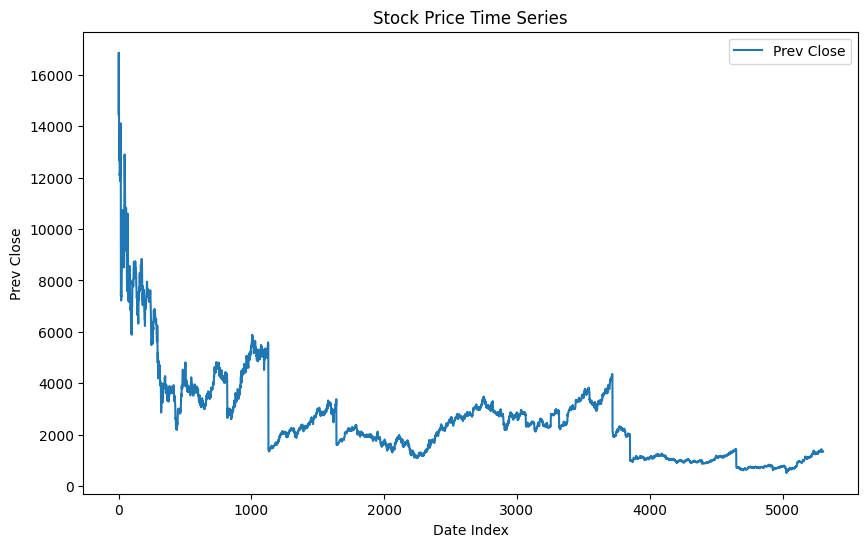

In [15]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(numeric_df.index, numeric_df[feature_names[0]], label=feature_names[0])

plt.title('Stock Price Time Series')
plt.xlabel('Date Index')
plt.ylabel(feature_names[0])
plt.legend()
plt.show()

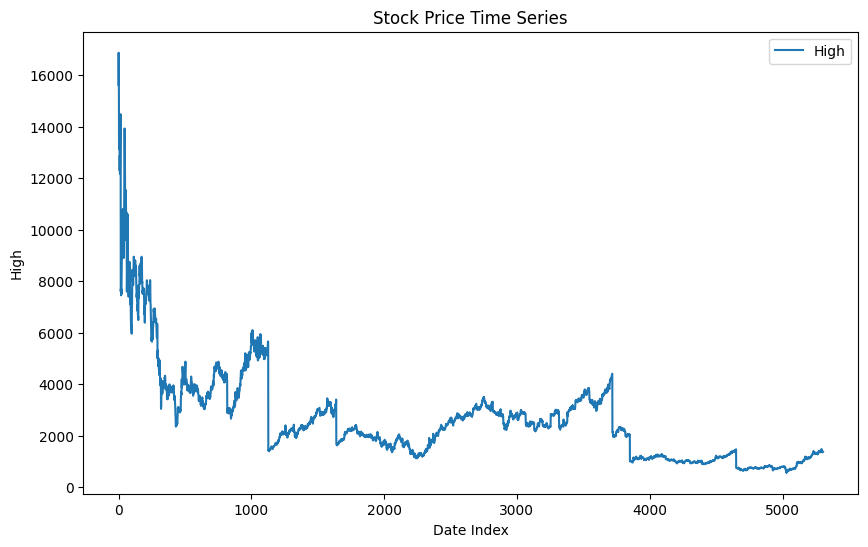

In [16]:

plt.figure(figsize=(10, 6))
plt.plot(numeric_df.index, numeric_df[feature_names[2]], label=feature_names[2])
plt.title('Stock Price Time Series')
plt.xlabel('Date Index')
plt.ylabel(feature_names[2])
plt.legend()
plt.show()

In [17]:
import numpy as np
data = numeric_df.values.astype(np.float32)
print("Data shape:", data.shape)

Data shape: (5306, 11)


In [18]:
data

array([[1.4467750e+04, 1.5625000e+04, 1.5625200e+04, ..., 8.0266574e+12,
        4.3496000e+04, 5.1977000e+04],
       [1.5625200e+04, 1.6800000e+04, 1.6875250e+04, ..., 9.3529372e+13,
        4.3496000e+04, 5.1977000e+04],
       [1.6855900e+04, 1.5701000e+04, 1.6250000e+04, ..., 2.5985165e+14,
        4.3496000e+04, 5.1977000e+04],
       ...,
       [1.3485000e+03, 1.3580000e+03, 1.3595000e+03, ..., 6.6037773e+14,
        1.3737600e+05, 2.8571340e+06],
       [1.3560000e+03, 1.3680000e+03, 1.3690000e+03, ..., 7.3610901e+14,
        1.1927700e+05, 3.1309450e+06],
       [1.3563500e+03, 1.3463000e+03, 1.3739000e+03, ..., 1.1372028e+15,
        1.3171800e+05, 5.4081130e+06]], shape=(5306, 11), dtype=float32)

In [19]:
INPUT_STEPS = 10
OUTPUT_STEPS = 5
TRAIN_RATIO = 0.8
BATCH_SIZE = 4

In [20]:
split_idx = int(len(data) * TRAIN_RATIO)
train_data1 = data[:split_idx]
test_data = data[split_idx:]

val_split_idx = int(len(train_data1) * 0.8)
train_data = train_data1[:val_split_idx]
val_data = train_data1[val_split_idx:]

In [21]:
train_data.shape, test_data.shape, val_data.shape

((3395, 11), (1062, 11), (849, 11))

In [22]:
from sklearn.preprocessing import normalize
train_data_norm = normalize(train_data, norm='l2', axis=0)
test_data_norm = normalize(test_data, norm='l2', axis=0)
val_data_norm = normalize(val_data, norm='l2', axis=0)

In [23]:
def create_sequences(data_array, input_steps=10, output_steps=5, overlap=1):
    X, y = [], []
    total_len = len(data_array)

    stride = input_steps - overlap
    if stride <=0 :
        raise ValueError("Overlap must be smaller than input steps")
    
    for i in range(0, total_len - input_steps - output_steps + 1, stride):
        X.append(data_array[i:i + input_steps])
        y.append(data_array[i + input_steps: i + input_steps + output_steps])
    
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

In [24]:
X_train, y_train = create_sequences(train_data_norm, INPUT_STEPS, OUTPUT_STEPS, overlap=8)
X_test, y_test = create_sequences(test_data_norm, INPUT_STEPS, OUTPUT_STEPS, overlap=8)
X_val, y_val = create_sequences(val_data_norm, INPUT_STEPS, OUTPUT_STEPS, overlap=8)


print("X_train: ", X_train.shape, "y_train: ", y_train.shape)
print("X_test: ", X_test.shape, "y_test: ", y_test.shape)
print("X_val: ", X_val.shape, "y_val: ", y_val.shape)

X_train:  (1691, 10, 11) y_train:  (1691, 5, 11)
X_test:  (524, 10, 11) y_test:  (524, 5, 11)
X_val:  (418, 10, 11) y_val:  (418, 5, 11)


In [25]:
import torch
from torch.utils.data import Dataset, DataLoader

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [26]:
train_dataset = TimeSeriesDataset(X_train, y_train)
test_dataset = TimeSeriesDataset(X_test, y_test)
val_dataset = TimeSeriesDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [27]:
import torch.nn as nn
class LSTMForecaster(nn.Module):
    def __init__(self):
        super(LSTMForecaster, self).__init__()
        self.lstm = nn.LSTM(11, 10, batch_first=True)
        self.fc = nn.Linear(10, 5 * 11)
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out.view(-1, 5, 11)

In [28]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [29]:
model = LSTMForecaster().to(device)
lr=0.0001
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10)

In [30]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    return running_loss / len(loader.dataset)

In [31]:
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            preds = model(X_batch)

            loss = criterion(preds, y_batch)
            running_loss += loss.item() * X_batch.size(0)

            all_preds.append(preds.cpu())
            all_targets.append(y_batch.cpu())

    avg_loss = running_loss / len(loader.dataset)
    all_preds = torch.cat(all_preds, dim=0).numpy()
    all_targets = torch.cat(all_targets, dim=0).numpy()

    return avg_loss, all_preds, all_targets

Without Early Stopping

In [32]:
EPOCHS = 100
train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, _, _= evaluate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

Epoch [1/100] | Train Loss: 0.024727 | Val Loss: 0.013690
Epoch [2/100] | Train Loss: 0.005161 | Val Loss: 0.001510
Epoch [3/100] | Train Loss: 0.000343 | Val Loss: 0.000608
Epoch [4/100] | Train Loss: 0.000087 | Val Loss: 0.000584
Epoch [5/100] | Train Loss: 0.000080 | Val Loss: 0.000548
Epoch [6/100] | Train Loss: 0.000079 | Val Loss: 0.000568
Epoch [7/100] | Train Loss: 0.000078 | Val Loss: 0.000541
Epoch [8/100] | Train Loss: 0.000078 | Val Loss: 0.000560
Epoch [9/100] | Train Loss: 0.000077 | Val Loss: 0.000544
Epoch [10/100] | Train Loss: 0.000076 | Val Loss: 0.000532
Epoch [11/100] | Train Loss: 0.000075 | Val Loss: 0.000529
Epoch [12/100] | Train Loss: 0.000074 | Val Loss: 0.000516
Epoch [13/100] | Train Loss: 0.000073 | Val Loss: 0.000517
Epoch [14/100] | Train Loss: 0.000072 | Val Loss: 0.000499
Epoch [15/100] | Train Loss: 0.000071 | Val Loss: 0.000503
Epoch [16/100] | Train Loss: 0.000069 | Val Loss: 0.000491
Epoch [17/100] | Train Loss: 0.000067 | Val Loss: 0.000471
Epoch 

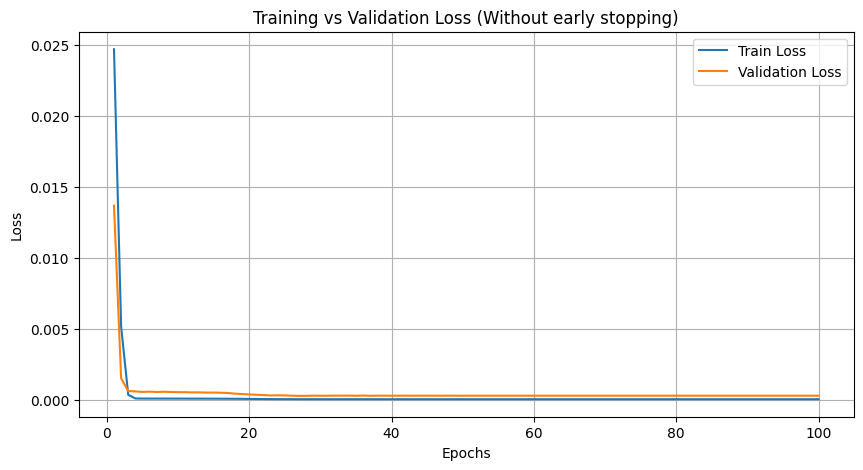

In [33]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (Without early stopping)")
plt.legend()
plt.grid(True)

plt.show()

With Early Stopping

In [34]:
model = LSTMForecaster().to(device)
lr=0.0001
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10)

In [35]:
EPOCHS = 100
PATIENCE = 10
train_losses = []
val_losses = []
best_val_loss = float('inf')
epochs_no_improve = 0

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, _, _= evaluate(model, val_loader, criterion, device)

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {train_loss :.6f} | Val Loss: {val_loss :.6f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0

        torch.save(model.state_dict(), "best_model.pt")
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= PATIENCE:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break


Epoch [1/100] | Train Loss: 0.022636 | Val Loss: 0.012856
Epoch [2/100] | Train Loss: 0.005744 | Val Loss: 0.002121
Epoch [3/100] | Train Loss: 0.000740 | Val Loss: 0.000753
Epoch [4/100] | Train Loss: 0.000145 | Val Loss: 0.000600
Epoch [5/100] | Train Loss: 0.000083 | Val Loss: 0.000563
Epoch [6/100] | Train Loss: 0.000078 | Val Loss: 0.000571
Epoch [7/100] | Train Loss: 0.000077 | Val Loss: 0.000559
Epoch [8/100] | Train Loss: 0.000075 | Val Loss: 0.000564
Epoch [9/100] | Train Loss: 0.000074 | Val Loss: 0.000521
Epoch [10/100] | Train Loss: 0.000073 | Val Loss: 0.000529
Epoch [11/100] | Train Loss: 0.000072 | Val Loss: 0.000509
Epoch [12/100] | Train Loss: 0.000070 | Val Loss: 0.000523
Epoch [13/100] | Train Loss: 0.000069 | Val Loss: 0.000522
Epoch [14/100] | Train Loss: 0.000067 | Val Loss: 0.000473
Epoch [15/100] | Train Loss: 0.000065 | Val Loss: 0.000462
Epoch [16/100] | Train Loss: 0.000062 | Val Loss: 0.000468
Epoch [17/100] | Train Loss: 0.000060 | Val Loss: 0.000429
Epoch 

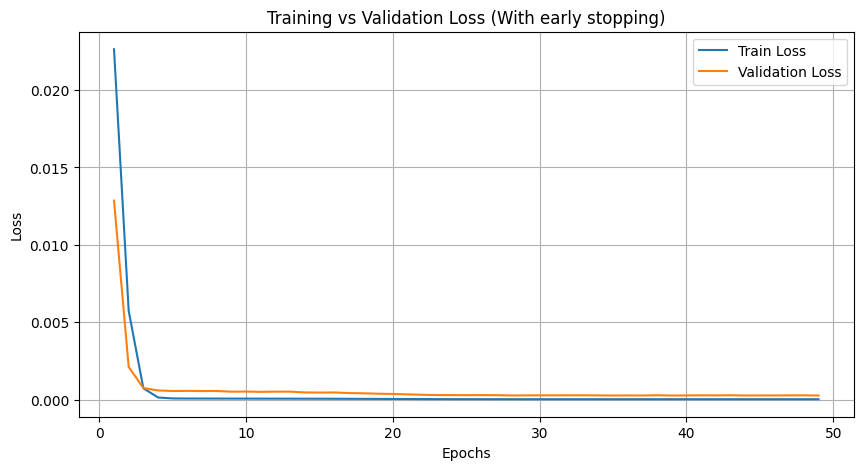

In [36]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (With early stopping)")
plt.legend()
plt.grid(True)

plt.show()

In [37]:
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [38]:
test_loss, predictions, targets = evaluate(model, test_loader, criterion, device)
print("Test Loss: ", test_loss )

Test Loss:  0.00019860684368243968


In [39]:
predictions.shape, targets.shape

((524, 5, 11), (524, 5, 11))

In [40]:
predictions

array([[[ 2.71416754e-02,  2.75446773e-02,  2.72937864e-02, ...,
          1.69184692e-02,  1.88967139e-02,  4.56134602e-03],
        [ 2.83885598e-02,  2.84231305e-02,  2.64519751e-02, ...,
          1.71847716e-02,  1.51525289e-02,  4.96467948e-03],
        [ 2.82889754e-02,  2.51452699e-02,  2.70831063e-02, ...,
          1.65490359e-02,  1.59231648e-02,  5.88817522e-03],
        [ 2.76074111e-02,  2.78873891e-02,  2.70181671e-02, ...,
          1.46745145e-02,  1.24744028e-02,  5.41874766e-03],
        [ 2.73338407e-02,  2.70924866e-02,  2.81699412e-02, ...,
          1.80147886e-02,  1.49996318e-02,  5.69313020e-03]],

       [[ 2.65114531e-02,  2.64245719e-02,  2.69878954e-02, ...,
          1.80057473e-02,  2.00170055e-02,  7.09890574e-03],
        [ 2.76138335e-02,  3.02939713e-02,  2.56164223e-02, ...,
          1.80642381e-02,  1.55181140e-02,  6.92389905e-03],
        [ 2.99402773e-02,  2.26801336e-02,  2.67203897e-02, ...,
          1.42198205e-02,  1.75097659e-02,  6.93077

In [41]:
preds_2d = predictions.reshape(-1, predictions.shape[-1])
targets_2d = targets.reshape(-1, targets.shape[-1])
preds_2d.shape, targets_2d.shape

((2620, 11), (2620, 11))

In [42]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

mse = mean_squared_error(targets_2d, preds_2d)
rmse = np.sqrt(mse)
mae = mean_absolute_error(targets_2d, preds_2d)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)

MSE: 0.00019860691099893302
RMSE: 0.014092796422248248
MAE: 0.00705484114587307


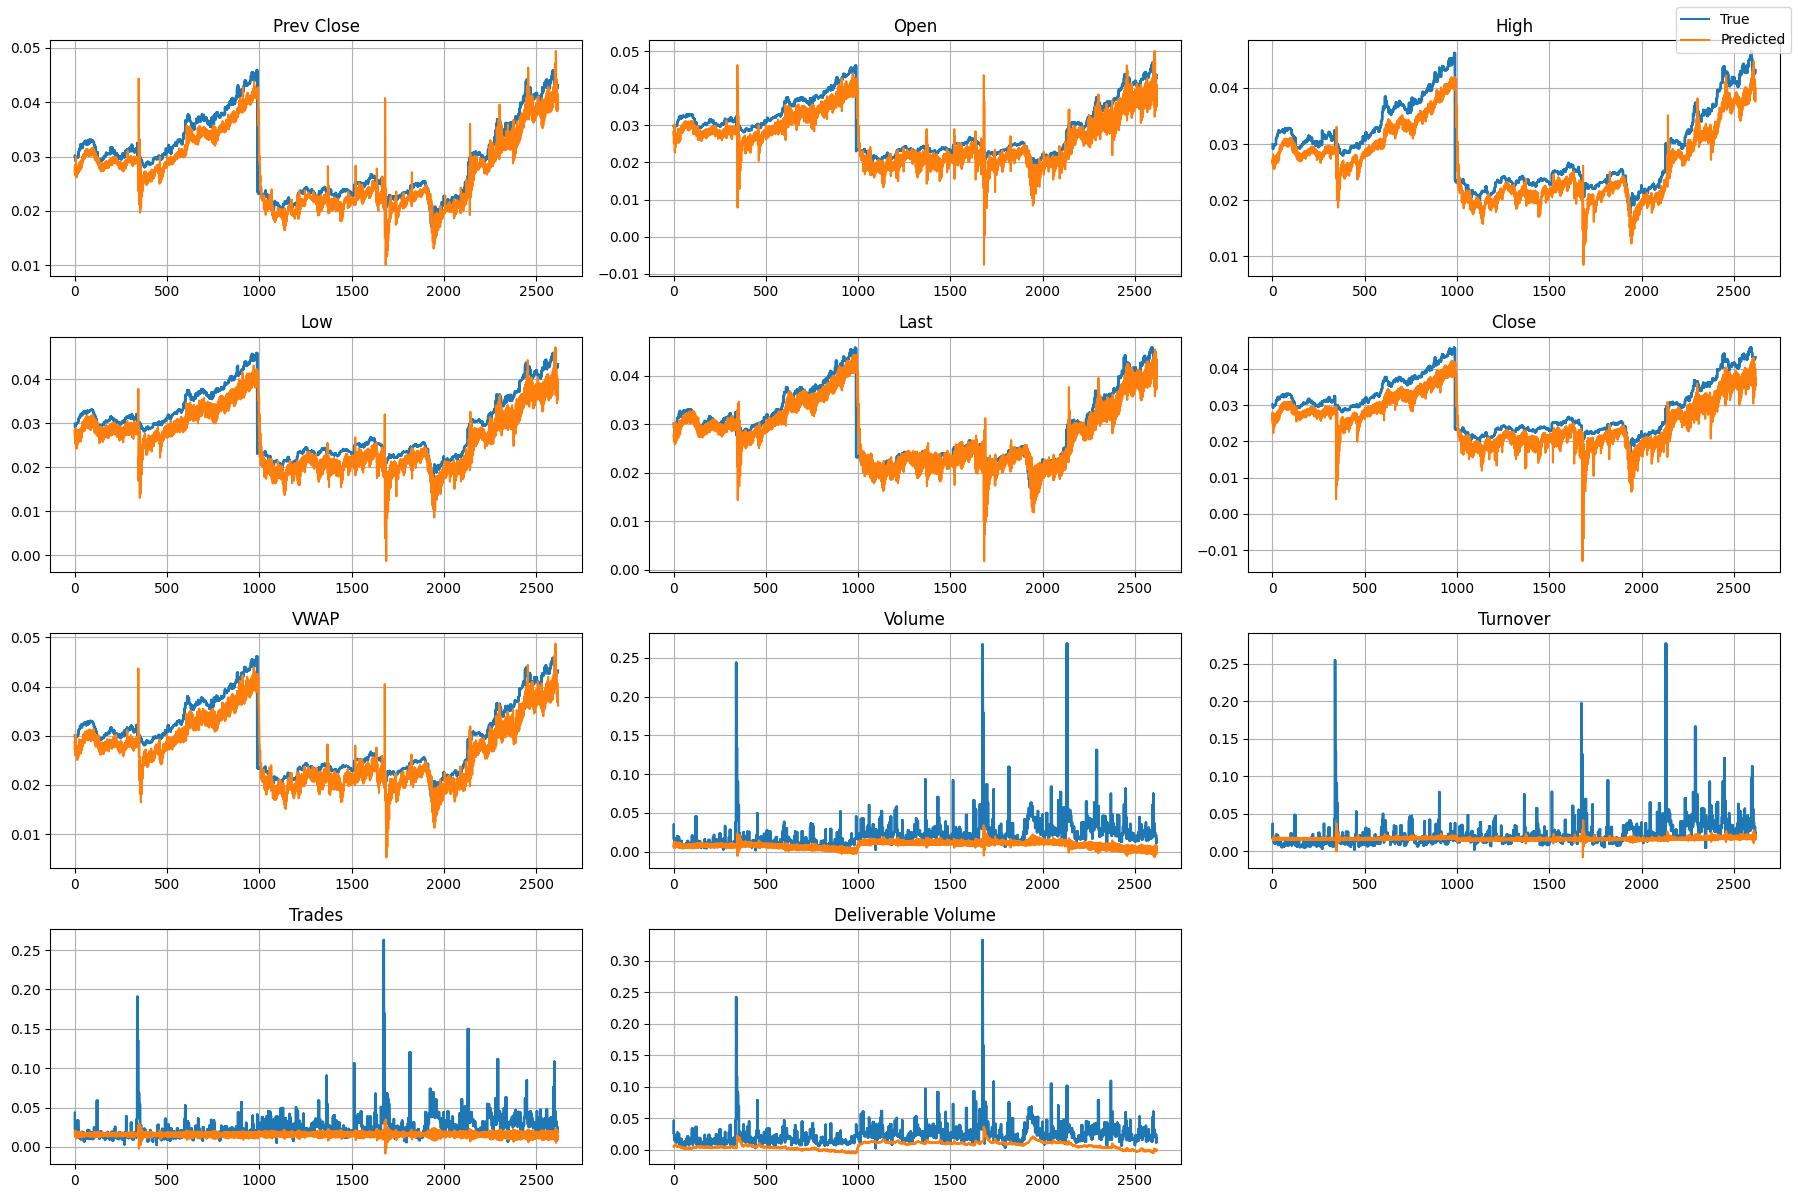

In [43]:
import matplotlib.pyplot as plt

num_features = predictions.shape[-1]

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18, 12))
axes = axes.flatten()

for i in range(num_features):
    pred_feature = predictions[:, :, i].reshape(-1)
    true_feature = targets[:, :, i].reshape(-1)

    axes[i].plot(true_feature, label="True")
    axes[i].plot(pred_feature, label="Predicted")
    axes[i].set_title(feature_names[i])
    axes[i].grid(True)

fig.delaxes(axes[-1])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')

plt.tight_layout()
plt.show()

10-Fold Cross Validation

In [44]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=10)

all_train_losses = []
all_val_losses = []

fold = 1

for train_idx, val_idx in tscv.split(train_data1):

    print(f"\nFold {fold}")
    
    train_data = train_data1[train_idx]
    val_data = train_data1[val_idx]

    train_data_norm = normalize(train_data, axis=0)
    val_data_norm = normalize(val_data, axis=0)

    X_train, y_train = create_sequences(train_data_norm, INPUT_STEPS, OUTPUT_STEPS)
    X_val, y_val = create_sequences(val_data_norm, INPUT_STEPS, OUTPUT_STEPS)

    train_dataset = TimeSeriesDataset(X_train, y_train)
    val_dataset = TimeSeriesDataset(X_val, y_val)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

    model = LSTMForecaster().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_loss = float('inf')
    patience = 10
    epochs_no_improve = 0

    train_losses = []
    val_losses = []

    for epoch in range(100):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, _, _ = evaluate(model, val_loader, criterion, device)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"Fold {fold} | Epoch {epoch+1} | Train: {train_loss:.6f} | Val: {val_loss:.6f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0

            torch.save(model.state_dict(), f"best_model_fold_{fold}.pt")
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    all_train_losses.append(train_losses)
    all_val_losses.append(val_losses)

    print(f"Fold {fold} Best Val Loss: {best_val_loss:.6f}")
    fold += 1


Fold 1
Fold 1 | Epoch 1 | Train: 0.040642 | Val: 0.040024
Fold 1 | Epoch 2 | Train: 0.039531 | Val: 0.038949
Fold 1 | Epoch 3 | Train: 0.038475 | Val: 0.037928
Fold 1 | Epoch 4 | Train: 0.037473 | Val: 0.036958
Fold 1 | Epoch 5 | Train: 0.036521 | Val: 0.036036
Fold 1 | Epoch 6 | Train: 0.035614 | Val: 0.035154
Fold 1 | Epoch 7 | Train: 0.034746 | Val: 0.034310
Fold 1 | Epoch 8 | Train: 0.033914 | Val: 0.033497
Fold 1 | Epoch 9 | Train: 0.033113 | Val: 0.032713
Fold 1 | Epoch 10 | Train: 0.032339 | Val: 0.031954
Fold 1 | Epoch 11 | Train: 0.031589 | Val: 0.031217
Fold 1 | Epoch 12 | Train: 0.030860 | Val: 0.030499
Fold 1 | Epoch 13 | Train: 0.030150 | Val: 0.029799
Fold 1 | Epoch 14 | Train: 0.029457 | Val: 0.029114
Fold 1 | Epoch 15 | Train: 0.028778 | Val: 0.028442
Fold 1 | Epoch 16 | Train: 0.028112 | Val: 0.027782
Fold 1 | Epoch 17 | Train: 0.027458 | Val: 0.027132
Fold 1 | Epoch 18 | Train: 0.026814 | Val: 0.026492
Fold 1 | Epoch 19 | Train: 0.026180 | Val: 0.025861
Fold 1 | Epoc

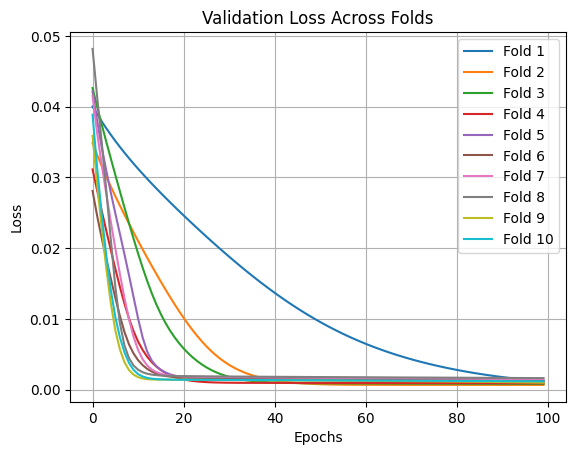

In [45]:
for i in range(len(all_train_losses)):
    plt.plot(all_val_losses[i], label=f"Fold {i+1}")

plt.title("Validation Loss Across Folds")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()